# Digital Image Processing — Student Assignment Notebook

**Spring 2026**  
**Topic:** Image I/O, grayscale/binary, cropping (ROI), color spaces, and basic arithmetic operations


## 0) Environment check

In [1]:
# Imports (run once)
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

print("OpenCV:", cv2.__version__)

IMAGE_PATH = "flower.jpg"

OpenCV: 4.13.0


## Helper functions (provided)

In [2]:
def to_rgb(img_bgr_or_rgb):
    if img_bgr_or_rgb is None:
        raise ValueError("Image is None. Check the path or loading step.")
    img = img_bgr_or_rgb
    if img.ndim == 2:
        return img
    return img

def load_image(path=None):
    if path and os.path.exists(path):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise ValueError(f"Failed to read: {path}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    return data.astronaut()

def show_side_by_side(img1, img2, title1="Image 1", title2="Image 2", cmap1=None, cmap2=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img1, cmap=cmap1); plt.title(title1); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img2, cmap=cmap2); plt.title(title2); plt.axis('off')
    plt.axis('off')
    plt.show()

def clip_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

## 1) Load an image

Image shape (H, W, C): (833, 1280, 3) | dtype: uint8


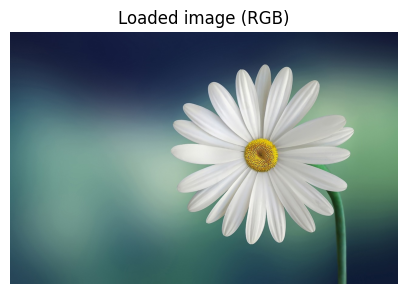

In [3]:
img = load_image(IMAGE_PATH)
print("Image shape (H, W, C):", img.shape, "| dtype:", img.dtype)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()

## 2) Image I/O basics

### Task 2.1 — Inspect pixels

In [4]:
# TODO (Task 2.1): print two pixel values
h, w = img.shape[:2]
print("Top-left pixel:", img[0, 0])
print("Center pixel:", img[h//2, w//2])

Top-left pixel: [19 24 54]
Center pixel: [235 235 233]


**Task 2.1 (Answer):**  
The 3 numbers represent RGB channels - Red, Green, Blue intensity values (0-255 each).

### Task 2.2 — Save and re-load

Reloaded shape: (833, 1280, 3) | dtype: uint8


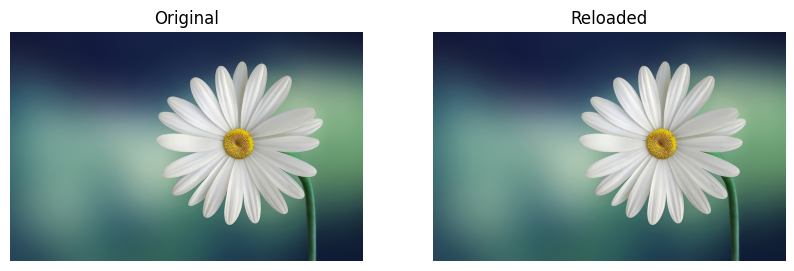

In [5]:
# TODO (Task 2.2): save and reload
out_path = "output_saved.png"

# OpenCV expects BGR when writing
bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite(out_path, bgr)

reloaded_bgr = cv2.imread(out_path, cv2.IMREAD_COLOR)
reloaded_rgb = cv2.cvtColor(reloaded_bgr, cv2.COLOR_BGR2RGB)

print("Reloaded shape:", reloaded_rgb.shape, "| dtype:", reloaded_rgb.dtype)
show_side_by_side(img, reloaded_rgb, "Original", "Reloaded")

## 3) Grayscale and binary images

### Task 3.1 — Convert to grayscale

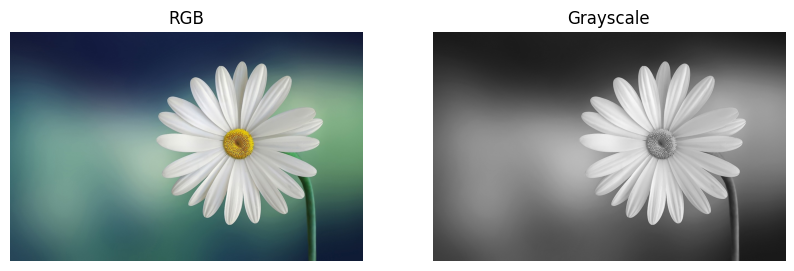

Gray shape: (833, 1280) | dtype: uint8


In [6]:
# TODO (Task 3.1): grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
show_side_by_side(img, gray, "RGB", "Grayscale", cmap2="gray")
print("Gray shape:", gray.shape, "| dtype:", gray.dtype)

### Task 3.2 — Threshold to binary

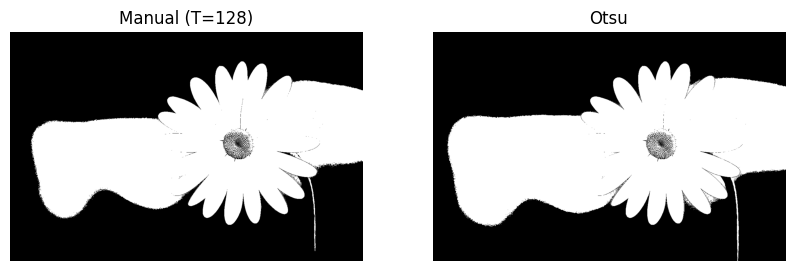

Otsu threshold chosen by OpenCV: 120.0


In [7]:
# TODO (Task 3.2): thresholding
th_manual = 128
_, binary_manual = cv2.threshold(gray, th_manual, 255, cv2.THRESH_BINARY)

_, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show_side_by_side(binary_manual, binary_otsu, f"Manual (T={th_manual})", "Otsu", cmap1="gray", cmap2="gray")
print("Otsu threshold chosen by OpenCV:", _)

**Task 3.2 (Answer):**  
Otsu's method automatically finds the optimal threshold by maximizing between-class variance, while manual threshold requires user input. Otsu works better for images with bimodal histograms.

## 4) Cropping (ROI)

### Task 4.1 — Crop a region of interest

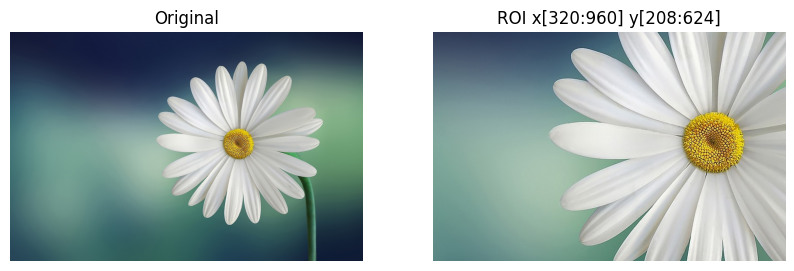

ROI shape: (416, 640, 3)


In [8]:
# TODO (Task 4.1): set ROI coordinates
h, w = img.shape[:2]
x1, y1 = int(0.25*w), int(0.25*h)
x2, y2 = int(0.75*w), int(0.75*h)

roi = img[y1:y2, x1:x2].copy()
show_side_by_side(img, roi, "Original", f"ROI x[{x1}:{x2}] y[{y1}:{y2}]")
print("ROI shape:", roi.shape)

### Task 4.2 — Explain coordinates
**Task 4.2 (Answer):**  
NumPy uses row-major order, so the first index represents rows (y-coordinate) and the second represents columns (x-coordinate), hence img[y, x].

## 5) Color spaces

### Task 5.1 — Convert RGB to HSV and visualize channels

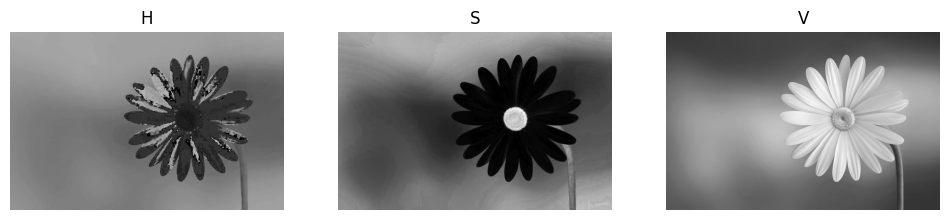

In [9]:
# TODO (Task 5.1): HSV conversion and channel display
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

plt.figure(figsize=(12,3))
for i, (ch, name) in enumerate([(H,"H"), (S,"S"), (V,"V")], start=1):
    plt.subplot(1,3,i); plt.imshow(ch, cmap="gray"); plt.title(name); plt.axis("off")
plt.show()

## 6) Basic arithmetic operations on images

### 6.1 Subtracting an intensity (darkening)

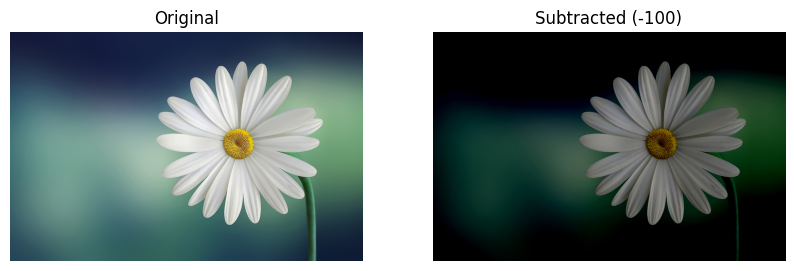

In [10]:
sub_val = 100
img_sub = cv2.subtract(img, sub_val)

show_side_by_side(img, img_sub, "Original", f"Subtracted (-{sub_val})")

**Task 6.1 (Answer):**
1. Increasing sub_val makes the image darker
2. The image gets darker because pixel values are reduced by the subtraction amount

### 6.2 Subtract from *red channel only*

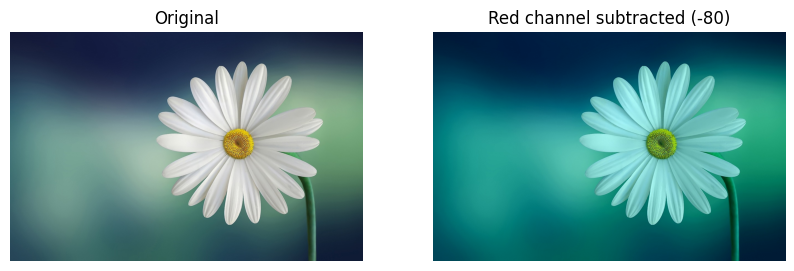

In [11]:
# TODO (Task 6.2): subtract from Red channel only
sub_val_r = 80

img_red_only = img.copy()
img_red_only[:,:,0] = cv2.subtract(img_red_only[:,:,0], sub_val_r)

show_side_by_side(img, img_red_only, "Original", f"Red channel subtracted (-{sub_val_r})")

### 6.3 Adding an intensity (brightening)

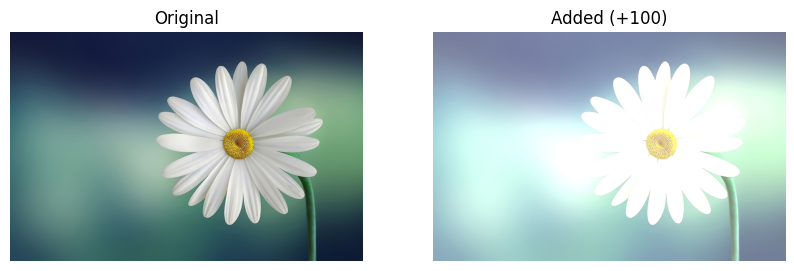

In [12]:
add_val = 100
img_add = cv2.add(img, add_val)

show_side_by_side(img, img_add, "Original", f"Added (+{add_val})")

**Task 6.3 (Answer):**
1. Increasing add_val makes the image brighter
2. The image gets brighter because pixel values are increased by the addition amount

### 6.4 Add to *red channel only*

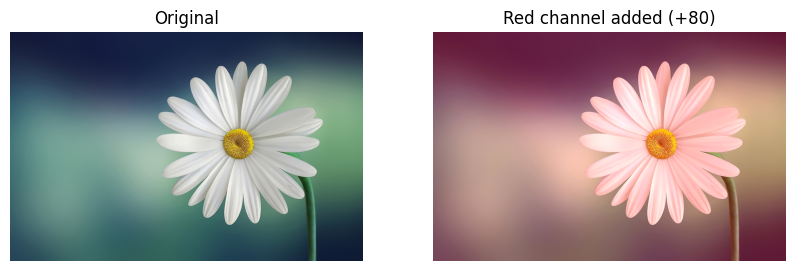

In [13]:
# TODO (Task 6.4): add to Red channel only
add_val_r = 80

img_red_only_add = img.copy()
img_red_only_add[:,:,0] = cv2.add(img_red_only_add[:,:,0], add_val_r)

show_side_by_side(img, img_red_only_add, "Original", f"Red channel added (+{add_val_r})")

### 6.5 Multiplying by a constant (contrast/brightness change)

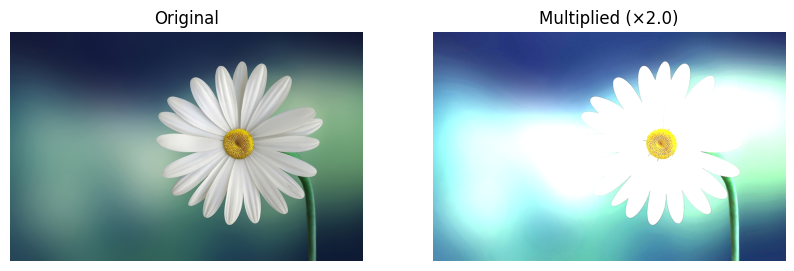

In [14]:
factor = 2.0

img_f = img.astype(np.float32)
img_mul = clip_uint8(img_f * factor)

show_side_by_side(img, img_mul, "Original", f"Multiplied (×{factor})")

**Task 6.5 (Answer):**
Multiplying by factor > 1 increases contrast (brighter), factor < 1 decreases contrast (darker). This scales all pixel values proportionally.

### 6.6 Dividing by a constant

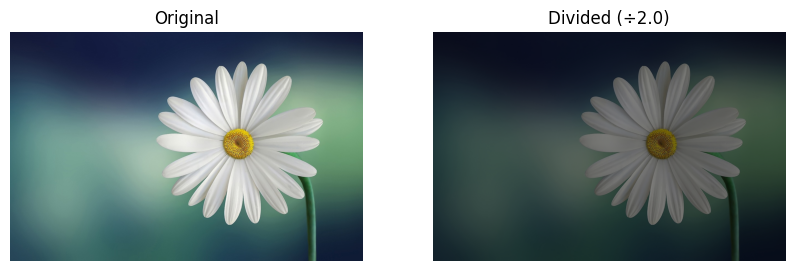

In [15]:
divisor = 2.0

img_f = img.astype(np.float32)
img_div = clip_uint8(img_f / divisor)

show_side_by_side(img, img_div, "Original", f"Divided (÷{divisor})")

**Task 6.6 (Answer):**
Dividing by > 1 darkens the image, dividing by < 1 brightens it (similar to multiplication but inverted).

## 7) Mini-report (required)

This assignment covered fundamental image processing techniques using Python libraries. Key learnings include:
- Different libraries load images in different formats (PIL, BGR in OpenCV)
- Image transformations: grayscale, binary thresholding (manual and Otsu)
- Arithmetic operations modify brightness/contrast
The most useful operations were Otsu's thresholding for automatic binarization and HSV conversion for color-based image analysis.